### Only to be used locally, venv works properly there

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path
import beastform4r as bfm

In [41]:
n_leaves = 30
birth_rate = 2.0
death_rate = 0.5

tree = bfm.Tree(n_leaves=n_leaves, method='yule',
            birth_rate=birth_rate)

independent = tree.generate_independent_data(
    n_sites=100,
    gain_rate=0.04,
    loss_rate=0.06,
    ascertain=True)

dependent = tree.generate_dependent_data(
    n_indep_sites=200,
    tiers=2,
    gain_rate=0.04,
    loss_rate=0.06,
    site_dep_prob=0.7,
    site_dep_mean=10,
    ascertain=True
)

print(dependent.shape)

# write_xml_file("templates/template_yule.xml", independent, "yulei_test")

# # Dataset B: weakly dependent sites
# dependent = generate_dependent_dataset(
#     tree, languages,
#     n_blocks=60,
#     block_size=5
# )
# dependent = ascertain(dependent)

print("\nIndependent (head):")
print(independent.head())

# print("\nDependent (head):")
# print(dependent.head())

Generated yule tree with 30 leaves.
(490, 30)

Independent (head):
       t3  t4  t25  t26  t6  t2  t15  t16  t9  t10  ...  t14  t12  t7  t8  \
cog_0   0   0    0    0   0   0    0    0   0    0  ...    1    1   1   1   
cog_1   0   0    0    0   0   0    0    0   0    0  ...    0    0   0   0   
cog_2   0   0    0    0   0   0    0    0   0    0  ...    1    1   1   1   
cog_3   1   1    0    0   1   1    1    1   1    1  ...    1    1   1   1   
cog_4   0   0    0    0   0   0    0    0   0    0  ...    0    1   0   0   

       t27  t28  t18  t21  t29  t30  
cog_0    0    0    0    0    0    0  
cog_1    0    0    0    0    0    0  
cog_2    0    0    0    0    0    0  
cog_3    1    1    1    1    0    0  
cog_4    0    0    0    0    0    0  

[5 rows x 30 columns]


In [4]:
(independent.to_numpy())[1]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0])

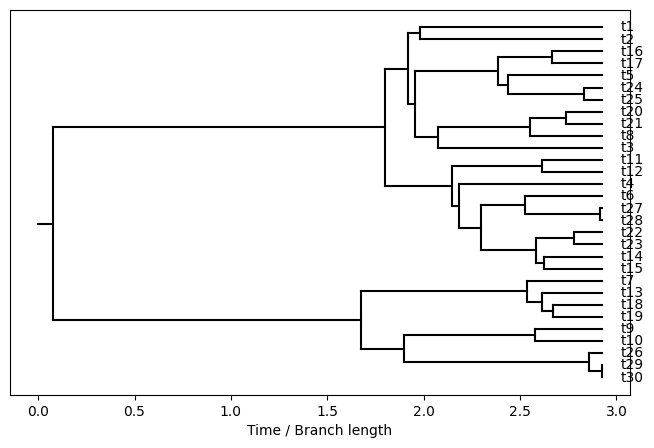

In [8]:
tree.plot()

In [9]:
independent['t2'].values, independent['t4'].values

print(sum(independent['t4'].values == independent['t3'].values)/len(independent['t1'].values))

0.8761609907120743


# Postprocessing Analysis

In [ ]:
rows = []
n_leaves = 30
for sites in [10, 20, 50, 100, 200]:
    for seed in [1, 2, 3, 4, 5]:
        prefix = f'run_sites{sites}_seed{seed}'
        dataset = pd.read_csv(f"{prefix}/{prefix}_tree_comparison_results.csv")
        dataset = dataset.values
        n = len(dataset)
        for i in range(n):
            rf, _, indep = dataset[i]
            rows.append({
                "sites": sites,
                "seed": seed,
                "RF": rf,
                "datatype": indep
            })

df_long = pd.DataFrame(rows)

,sites,seed,RF,datatype
0,10,1,46,independent
1,10,1,46,independent
2,10,1,44,independent
3,10,1,42,independent
4,10,1,42,independent
...,...,...,...,...
450045,200,5,10,dependent
450046,200,5,10,dependent
450047,200,5,8,dependent
450048,200,5,12,dependent


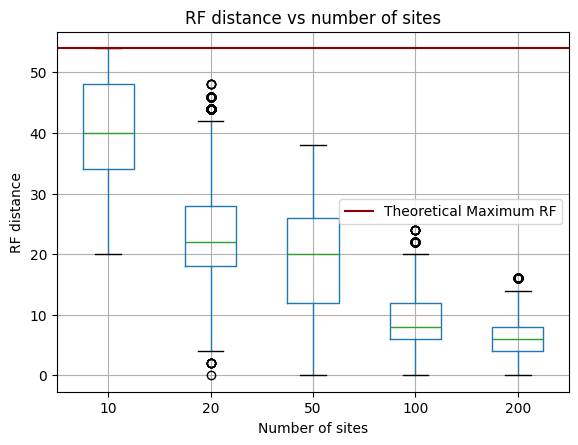

,mean,std
sites,,
10,40.440040,7.694108
20,23.613643,8.812490
50,18.967848,7.945103
100,9.338429,3.500760
200,6.618420,2.895647


In [37]:
df_indep = df_long[df_long['datatype'] == 'independent']
df_indep.boxplot(column="RF", by="sites")
plt.axhline(2*n_leaves-6, color='darkred', label='Theoretical Maximum RF')
plt.title("RF distance vs number of sites")
plt.suptitle("")
plt.xlabel("Number of sites")
plt.ylabel("RF distance")
plt.legend()
plt.show()
df_indep["nRF"] = df_indep["RF"]/(2*30-6)
df_summary = df_indep.groupby("sites")["RF"].agg(["mean", "std"])
df_summary

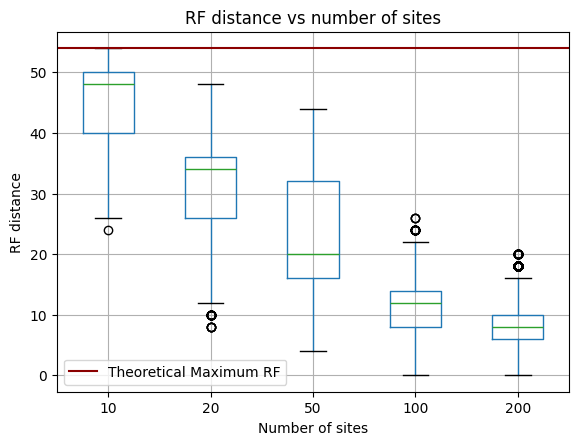

,mean,std
sites,,
10,44.909055,6.409820
20,31.113654,7.153782
50,23.024331,8.522535
100,11.395267,4.342928
200,8.079680,3.538726


In [39]:
df_dep = df_long[df_long['datatype'] == 'dependent']
df_dep.boxplot(column="RF", by="sites")
plt.axhline(2*n_leaves-6, color='darkred', label='Theoretical Maximum RF')
plt.title("RF distance vs number of sites")
plt.suptitle("")
plt.xlabel("Number of sites")
plt.ylabel("RF distance")
plt.legend()
plt.show()
df_dep["nRF"] = df_dep["RF"]/(2*30-6)
df_summary = df_dep.groupby("sites")["RF"].agg(["mean", "std"])
df_summary
